# Predicting Online Shopper Purchase Intent

Goal: predict whether an online shopping session ends in a purchase.
Data: UCI Online Shoppers Purchasing Intention dataset (12,330 sessions, 18 columns).
Tools: Python, pandas, scikit-learn, matplotlib.

In [11]:
import os
print(os.listdir())

['analysis.ipynb', 'archive', 'online_shoppers_intention.csv', 'shoppers.ipynb']


## 1. Loading the Data
The dataset has 12,330 sessions and no missing values. The target is `Revenue` (purchase or no purchase). Only about 15.5% of sessions end in a purchase, so the classes are imbalanced.

In [12]:
import pandas as pd

df = pd.read_csv("online_shoppers_intention.csv")
print(df.shape)
print(df.columns.tolist())
print()
print(df["Revenue"].value_counts())
print()
print(df.isnull().sum())

(12330, 18)
['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']

Revenue
False    10422
True      1908
Name: count, dtype: int64

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64


## 2. Exploring the Data
Buyers viewed more product pages (48 vs 29 on average), spent more time on them, and had much lower bounce and exit rates. New visitors converted more often than returning visitors (24.9% vs 13.9%), and November had the highest purchase rate (about 25%) while February had the lowest (about 1.6%).

In [13]:
print(df.groupby("Revenue")[["ProductRelated", "ProductRelated_Duration", "BounceRates", "ExitRates", "PageValues"]].mean())
print()
print(df.groupby("VisitorType")["Revenue"].mean())
print()
print(df.groupby("Month")["Revenue"].mean().sort_values())

         ProductRelated  ProductRelated_Duration  BounceRates  ExitRates  \
Revenue                                                                    
False         28.714642              1069.987809     0.025317   0.047378   
True          48.210168              1876.209615     0.005117   0.019555   

         PageValues  
Revenue              
False      1.975998  
True      27.264518  

VisitorType
New_Visitor          0.249115
Other                0.188235
Returning_Visitor    0.139323
Name: Revenue, dtype: float64

Month
Feb     0.016304
Mar     0.100682
June    0.100694
May     0.108502
Dec     0.125072
Jul     0.152778
Aug     0.175520
Sep     0.191964
Oct     0.209472
Nov     0.253502
Name: Revenue, dtype: float64


## 3. Baseline Model
A model that always predicts "no purchase" already reaches 84.5% accuracy, so accuracy alone is misleading here. A first Random Forest reached 90% accuracy but found only 51% of buyers (recall). From here on I evaluate with precision, recall and F1 for the buyer class.

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import classification_report

X = pd.get_dummies(df.drop(columns=["Revenue"]))
y = df["Revenue"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# النموذج الغبي (baseline): بيقول "ما رح يشتري" للكل
dummy = DummyClassifier(strategy="most_frequent")
dummy.fit(X_train, y_train)
print("Baseline accuracy:", dummy.score(X_test, y_test))
print()

# نموذجنا
model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced")
model.fit(X_train, y_train)
print(classification_report(y_test, model.predict(X_test)))

Baseline accuracy: 0.8450932684509327

              precision    recall  f1-score   support

       False       0.92      0.97      0.94      2084
        True       0.76      0.51      0.61       382

    accuracy                           0.90      2466
   macro avg       0.84      0.74      0.78      2466
weighted avg       0.89      0.90      0.89      2466



## 4. Comparing Models (Cross-Validation)
I compared Logistic Regression, Random Forest and Gradient Boosting using 5-fold stratified cross-validation. Gradient Boosting performed best overall (F1 0.656, ROC-AUC 0.932).

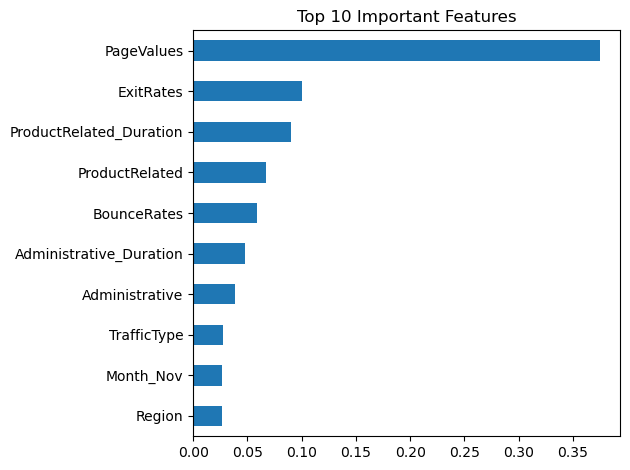

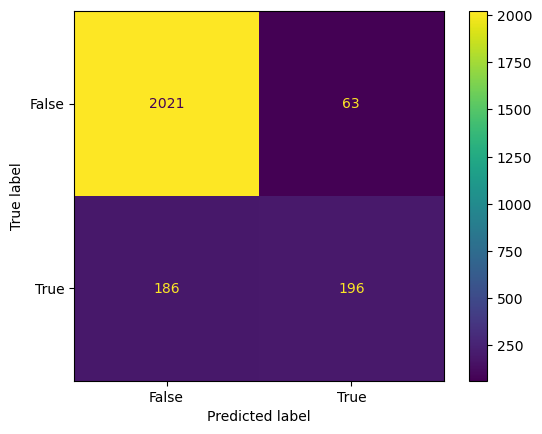

In [15]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import ConfusionMatrixDisplay

# أهم 10 أعمدة بالنسبة للنموذج
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
importances.sort_values().plot(kind="barh", title="Top 10 Important Features")
plt.tight_layout()
plt.show()

# مصفوفة الأخطاء
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test)
plt.show()

## 5. Hyperparameter Tuning
I tuned Gradient Boosting with randomized search (20 combinations, scored by F1) on the training set only, keeping 20% of the data aside for final testing. Cross-validated F1 improved from 0.656 to 0.673.

In [16]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier

X = pd.get_dummies(df.drop(columns=["Revenue"]))
y = df["Revenue"].astype(int)

models = {
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, class_weight="balanced")),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42, class_weight="balanced"),
    "Gradient Boosting": HistGradientBoostingClassifier(random_state=42),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rows = []
for name, m in models.items():
    s = cross_validate(m, X, y, cv=cv, scoring=["precision", "recall", "f1", "roc_auc"])
    rows.append({
        "model": name,
        "precision": s["test_precision"].mean(),
        "recall": s["test_recall"].mean(),
        "f1": s["test_f1"].mean(),
        "roc_auc": s["test_roc_auc"].mean(),
    })

results = pd.DataFrame(rows).set_index("model").round(3)
results

,precision,recall,f1,roc_auc
model,,,,
Logistic Regression,0.516,0.757,0.613,0.903
Random Forest,0.749,0.540,0.627,0.927
Gradient Boosting,0.722,0.601,0.656,0.932


## 6. Threshold Tuning
The default threshold of 0.5 misses many buyers. I chose a lower threshold (0.30) using cross-validation on the training data only. On the test set, recall rose from 0.60 to 0.73, while precision fell from 0.74 to 0.61. F1 stayed about the same (0.66 vs 0.67), so this is a trade-off, not a free improvement. A lower threshold suits cheap actions such as reminder emails.

In [17]:
from sklearn.model_selection import train_test_split, RandomizedSearchCV

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

param_dist = {
    "learning_rate": [0.03, 0.05, 0.1, 0.2],
    "max_depth": [3, 5, 7, None],
    "max_leaf_nodes": [15, 31, 63],
    "min_samples_leaf": [20, 50, 100],
    "l2_regularization": [0, 0.1, 1.0],
}

search = RandomizedSearchCV(
    HistGradientBoostingClassifier(max_iter=200, random_state=42),
    param_distributions=param_dist,
    n_iter=20, scoring="f1", cv=cv, random_state=42, n_jobs=-1)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV F1:", round(search.best_score_, 3))

Best params: {'min_samples_leaf': 100, 'max_leaf_nodes': 15, 'max_depth': None, 'learning_rate': 0.03, 'l2_regularization': 0.1}
Best CV F1: 0.673


## 7. Testing Without PageValues
`PageValues` is calculated by Google Analytics from the pages a visitor viewed, so it partly leaks the target. Without it, ROC-AUC drops from 0.932 to 0.771 and F1 (buyer class, tuned threshold) drops from 0.67 to 0.39. The model is still better than random guessing (precision 0.33 vs about 0.15 for random), but much weaker.

Best threshold: 0.297


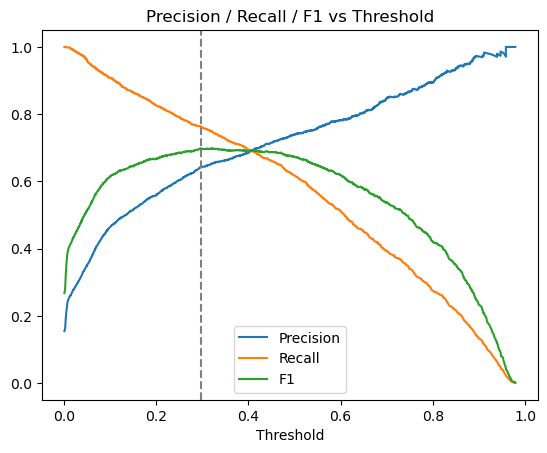

Default threshold (0.5):
              precision    recall  f1-score   support

           0       0.93      0.96      0.95      2084
           1       0.74      0.60      0.66       382

    accuracy                           0.91      2466
   macro avg       0.84      0.78      0.80      2466
weighted avg       0.90      0.91      0.90      2466

Tuned threshold (0.30):
              precision    recall  f1-score   support

           0       0.95      0.92      0.93      2084
           1       0.61      0.73      0.67       382

    accuracy                           0.89      2466
   macro avg       0.78      0.82      0.80      2466
weighted avg       0.90      0.89      0.89      2466



In [18]:
import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, classification_report

best_model = search.best_estimator_

# احتمالات من cross-validation على بيانات التدريب فقط
probs_cv = cross_val_predict(best_model, X_train, y_train, cv=cv, method="predict_proba")[:, 1]

precision, recall, thresholds = precision_recall_curve(y_train, probs_cv)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = np.argmax(f1_scores[:-1])
best_threshold = thresholds[best_idx]
print("Best threshold:", round(best_threshold, 3))

# رسم
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")
plt.plot(thresholds, f1_scores[:-1], label="F1")
plt.axvline(best_threshold, color="gray", linestyle="--")
plt.xlabel("Threshold")
plt.legend()
plt.title("Precision / Recall / F1 vs Threshold")
plt.show()

# التقييم النهائي على الاختبار
test_probs = best_model.predict_proba(X_test)[:, 1]
print("Default threshold (0.5):")
print(classification_report(y_test, (test_probs >= 0.5).astype(int)))
print(f"Tuned threshold ({best_threshold:.2f}):")
print(classification_report(y_test, (test_probs >= best_threshold).astype(int)))

## 7. Testing Without PageValues
`PageValues` is calculated by Google Analytics from the pages a visitor viewed, so it partly leaks the target. Without it, ROC-AUC drops from 0.932 to 0.771 and F1 (buyer class, tuned threshold) drops from 0.67 to 0.39. The model is still better than random guessing (precision 0.33 vs about 0.15 for random), but much weaker.

In [19]:
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, f1_score

X_train_np = X_train.drop(columns=["PageValues"])
X_test_np = X_test.drop(columns=["PageValues"])

model_np = clone(best_model)
model_np.fit(X_train_np, y_train)
probs_np = model_np.predict_proba(X_test_np)[:, 1]

print("With PageValues:")
print("  ROC-AUC:", round(roc_auc_score(y_test, test_probs), 3))
print("  F1 @0.5:", round(f1_score(y_test, test_probs >= 0.5), 3))
print()
print("Without PageValues:")
print("  ROC-AUC:", round(roc_auc_score(y_test, probs_np), 3))
print("  F1 @0.5:", round(f1_score(y_test, probs_np >= 0.5), 3))

With PageValues:
  ROC-AUC: 0.932
  F1 @0.5: 0.663

Without PageValues:
  ROC-AUC: 0.771
  F1 @0.5: 0.131


## 8. Feature Importance
Without `PageValues`, the most important features are `ExitRates`, `ProductRelated_Duration` and November (`Month_Nov`).

Best threshold without PageValues: 0.237
              precision    recall  f1-score   support

           0       0.90      0.82      0.86      2084
           1       0.33      0.49      0.39       382

    accuracy                           0.77      2466
   macro avg       0.61      0.65      0.62      2466
weighted avg       0.81      0.77      0.78      2466



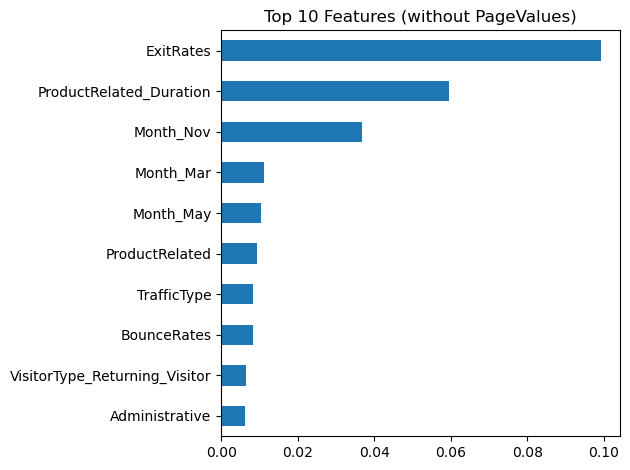

In [20]:
from sklearn.inspection import permutation_importance

# 1) أداء النموذج بدون PageValues بعد ضبط العتبة (من بيانات التدريب)
probs_np_cv = cross_val_predict(model_np, X_train_np, y_train, cv=cv, method="predict_proba")[:, 1]
p, r, t = precision_recall_curve(y_train, probs_np_cv)
f = 2 * p * r / (p + r + 1e-9)
thr_np = t[np.argmax(f[:-1])]
print("Best threshold without PageValues:", round(thr_np, 3))
print(classification_report(y_test, (probs_np >= thr_np).astype(int)))

# 2) أهمية الأعمدة (بالنموذج بدون PageValues)
pi = permutation_importance(model_np, X_test_np, y_test, scoring="roc_auc",
                            n_repeats=5, random_state=42, n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X_test_np.columns).sort_values(ascending=False).head(10)
imp.sort_values().plot(kind="barh", title="Top 10 Features (without PageValues)")
plt.tight_layout()
plt.show()